# k-Nearest Neighbor on CIFAR-10

This notebook demonstrates a from-scratch implementation of the **k-nearest neighbor (k-NN)** classifier on a subset of CIFAR-10.

## Goals
- load and inspect CIFAR-10
- represent images as vectors in a high-dimensional space
- train and evaluate a k-NN classifier
- compare three distance-computation implementations
- select the hyperparameter `k` by cross-validation

## Related source files
- `src/models/knn.py`
- `src/utils/data.py`


## 0. What is k-NN?

Given a test point $x$, the k-NN classifier:
1. computes the distance from $x$ to every training point,
2. finds the $k$ nearest training examples,
3. predicts the most common label among those neighbors.

In this notebook, each image is represented as a vector in $\mathbf{R}^{3072}$, since CIFAR-10 images have shape $32 \times 32 \times 3$.

## 1. Setup

The notebook is meant to live in `demos/`, with reusable code in `src/`.
The small path adjustment below lets the notebook import from the repository root when it is run locally.


In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import random
import numpy as np
import matplotlib.pyplot as plt

from src.models.knn import KNearestNeighbor
from src.utils.data import load_CIFAR10

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Optional convenience for local development
%load_ext autoreload
%autoreload 2


## 2. Load CIFAR-10

We first load the raw CIFAR-10 data. Each image has shape `(32, 32, 3)`.


In [2]:
import os
import urllib.request
import tarfile

# Update this path if your local data directory is different.
cifar10_dir = repo_root / "data" / "cifar-10-batches-py"

# Download dataset if it does not exist
if not cifar10_dir.exists():
    print("CIFAR-10 dataset not found. Downloading...")

    data_dir = repo_root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)

    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    archive_path = data_dir / "cifar-10-python.tar.gz"

    urllib.request.urlretrieve(url, archive_path)

    print("Extracting dataset...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_dir)

    print("Download complete.")

# Clean up old variables if the notebook has been run before.
for name in ["X_train", "y_train", "X_test", "y_test"]:
    if name in globals():
        del globals()[name]

# Load CIFAR-10
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print("Training data shape: ", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:     ", X_test.shape)
print("Test labels shape:   ", y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape: (50000,)
Test data shape:      (10000, 32, 32, 3)
Test labels shape:    (10000,)


## 3. Visualize a few examples

A quick visualization helps confirm both the data layout and the semantic variety across classes.


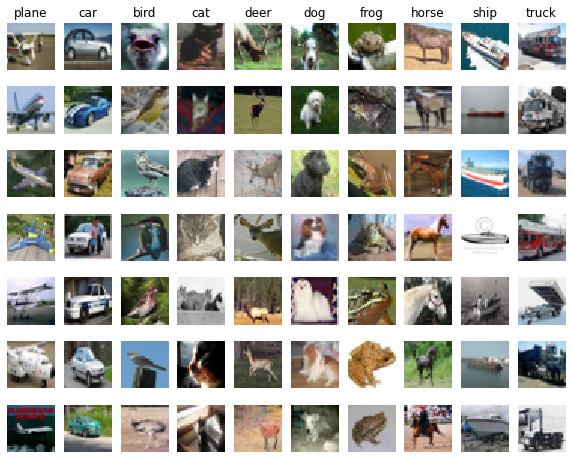

In [3]:
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

## 4. Subsample and reshape the data

For this demo, we use a smaller subset to keep computation manageable.
After subsampling, we flatten each image into a row vector so that k-NN can treat the data as points in Euclidean space.


In [4]:
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print("Flattened training data shape:", X_train.shape)
print("Flattened test data shape:    ", X_test.shape)


Flattened training data shape: (5000, 3072)
Flattened test data shape:     (500, 3072)


## 5. Train the classifier

For k-NN, training is just memorizing the training set.


In [5]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)


## 6. Compute the distance matrix with two loops

We begin with the most direct implementation.
If there are `num_test` test examples and `num_training` training examples, then the distance matrix has shape `(num_test, num_training)`.


In [6]:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)


(500, 5000)


## 7. Visualize the distance matrix

Each row corresponds to one test image, and each column corresponds to one training image.
Brighter entries indicate larger distances.


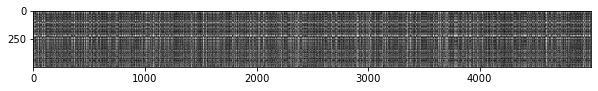

In [7]:
plt.imshow(dists, interpolation='none')
plt.show()


### Discussion: structured brightness patterns

Two visual patterns often stand out:

- **Bright rows** correspond to test images that are far from many training images. These are often outliers, unusually colored images, or images with a composition not well represented in the training subset.
- **Bright columns** correspond to training images that are far from many test images. These are training-set outliers or unusual examples.

This is a nice reminder that even before classification, the geometry of the data already reveals structure.


## 8. Inspect unusually distant examples

The extra inspection below keeps one of the most useful exploratory ideas from the original working notebook: identifying test and training images whose average distances are especially large.


Most distant test image index:    385
Most distant training image index: 4601


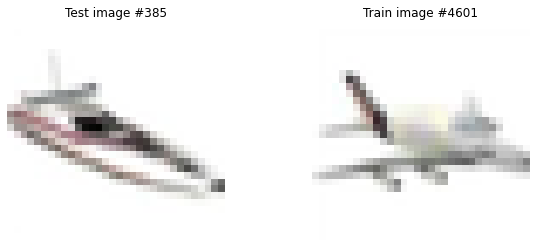

In [8]:
row_mean = np.mean(dists, axis=1)   # average distance for each test image
col_mean = np.mean(dists, axis=0)   # average distance for each training image

outlier_test_idx = np.argmax(row_mean)
outlier_train_idx = np.argmax(col_mean)

print("Most distant test image index:   ", outlier_test_idx)
print("Most distant training image index:", outlier_train_idx)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_test[outlier_test_idx].reshape(32, 32, 3).astype("uint8"))
plt.title(f"Test image #{outlier_test_idx}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train[outlier_train_idx].reshape(32, 32, 3).astype("uint8"))
plt.title(f"Train image #{outlier_train_idx}")
plt.axis("off")

plt.show()


## 9. Predict labels from the distance matrix

Once distances are known, prediction is a voting procedure among the nearest neighbors.
We start with the simplest choice, `k = 1`.


In [9]:
y_test_pred = classifier.predict_labels(dists, k=1)

num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (num_correct, num_test, accuracy))


Got 137 / 500 correct => accuracy: 0.274000


For raw-pixel k-NN on CIFAR-10, an accuracy around **27%** is typical here.


In [10]:
y_test_pred = classifier.predict_labels(dists, k=5)

num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (num_correct, num_test, accuracy))


Got 139 / 500 correct => accuracy: 0.278000


A slightly larger `k` often performs a bit better because it reduces sensitivity to individual noisy neighbors.


## 10. Note on preprocessing and distance choice

This demo uses the standard raw-pixel representation together with Euclidean distance.

A useful conceptual question is whether preprocessing always helps k-NN. For example, if one switches to L1 distance, then different normalization choices may interact with the geometry in different ways. There is no universal rule that every centering or scaling scheme improves nearest-neighbor performance; the answer depends on the distance metric and on which variations in the data are actually informative.


## 11. Speeding up distance computation

The two-loop implementation is the clearest, but it is slow.
We now compare it with partially vectorized and fully vectorized implementations.


In [11]:
dists_one = classifier.compute_distances_one_loop(X_test)

difference = np.linalg.norm(dists - dists_one, ord='fro')
print("One loop difference was: %f" % difference)
if difference < 0.001:
    print("Good! The distance matrices are the same")
else:
    print("Uh-oh! The distance matrices are different")


One loop difference was: 0.000000
Good! The distance matrices are the same


In [12]:
dists_two = classifier.compute_distances_no_loops(X_test)

difference = np.linalg.norm(dists - dists_two, ord='fro')
print("No loop difference was: %f" % difference)
if difference < 0.001:
    print("Good! The distance matrices are the same")
else:
    print("Uh-oh! The distance matrices are different")


No loop difference was: 0.000000
Good! The distance matrices are the same


In [13]:
def time_function(f, *args):
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print("Two loop version took %f seconds" % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print("One loop version took %f seconds" % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print("No loop version took %f seconds" % no_loop_time)


Two loop version took 22.393625 seconds
One loop version took 10.975750 seconds
No loop version took 0.230714 seconds


The fully vectorized version should be much faster. This is one of the central implementation lessons of the notebook: in numerical Python, vectorization matters.


## 12. Cross-validation

So far, the choice of `k` has been ad hoc.
We now use 5-fold cross-validation on the training set to choose `k` more systematically.


In [14]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds):
        X_val_fold = X_train_folds[i]
        y_val_fold = y_train_folds[i]

        X_train_cv = np.concatenate([X_train_folds[j] for j in range(num_folds) if j != i], axis=0)
        y_train_cv = np.concatenate([y_train_folds[j] for j in range(num_folds) if j != i], axis=0)

        classifier = KNearestNeighbor()
        classifier.train(X_train_cv, y_train_cv)

        y_val_pred = classifier.predict(X_val_fold, k=k)
        num_correct = np.sum(y_val_pred == y_val_fold)
        accuracy = float(num_correct) / len(y_val_fold)
        k_to_accuracies[k].append(accuracy)

for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print("k = %d, accuracy = %f" % (k, accuracy))


k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

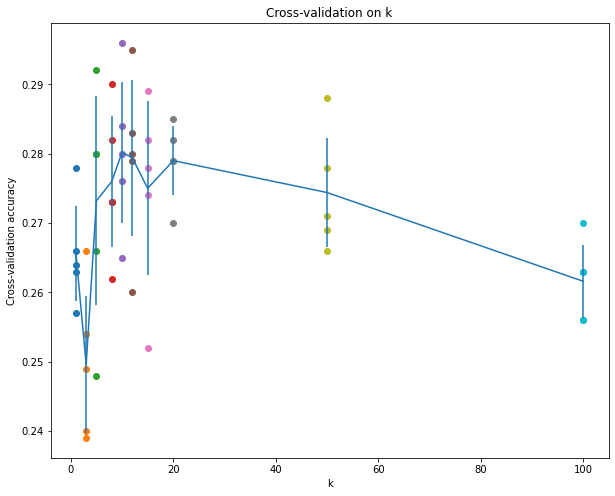

In [15]:
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

accuracies_mean = np.array([np.mean(v) for k, v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k, v in sorted(k_to_accuracies.items())])

plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title("Cross-validation on k")
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.show()


## 13. Final evaluation on the test set

We choose the best `k` from cross-validation, retrain on the full training subset, and evaluate once on the held-out test set.


In [16]:
best_k = 10

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (num_correct, num_test, accuracy))


Got 141 / 500 correct => accuracy: 0.282000


## 14. Takeaways

- k-NN is conceptually simple: it stores the training set and predicts by local voting.
- Raw-pixel k-NN is only a modest CIFAR-10 baseline, but it is still valuable pedagogically.
- The notebook illustrates the full supervised learning workflow: data representation, model fitting, validation, testing, and computational tradeoffs.
- The difference between two-loop and vectorized distance computation is a concrete example of why efficient numerical programming matters.


## 15. Conceptual checklist

In the original assignment, one of the conceptual checks asked which statements about k-NN are always true.

The correct takeaways are:

1. The decision boundary of k-NN is **not** generally linear.
2. The training error of 1-NN is always less than or equal to that of 5-NN, under the standard convention used here that each training point is its own nearest neighbor.
3. The test error of 1-NN is **not** always lower than that of 5-NN.
4. Prediction time does grow with the size of the training set.

These points are worth keeping because they summarize the main statistical and computational tradeoffs of the method.
